#**Maestría en Inteligencia Artificial Aplicada**
## TC5035.10
##**Curso: Proyecto Integrador**
###Tecnológico de Monterrey

---

**Docente Titular**: Dra. Grettel Barceló Alonso y Dr. Luis Eduardo Falcón

**Docente Asistente**: Veronica Guzman del Valle

**Docente Tutor**: Eduviges Ludivina Facundo Flores

**Docente del ITCJ Responsable**: Mtra. Yadira Dozal Assmar

#**Nombre del Proyecto:**
---
*"Modelado de serie de tiempo para pronosticar la demanda de prórrogas de licenciatura en ITCJ"*

---

#**Integrantes Equipo #13:**
* A01796362 Eduardo Perez Carrillo
* A01795907 Nancy Teresa Zapien García
* A01796060 Hugo Alberto Cuevas García

# **Avance 4 - MODELOS ALTERNATIVOS** (Reglas vs ML) **mensual con ceros** (2019–2025) + Pronóstico 2026–2027

Este notebook replica el flujo del baseline anterior, pero ahora convierte la serie semestral a **mensual** generando una malla completa de meses.

Como el origen solo tiene datos “reales” en **enero** y **julio** de cada año (S1/S2), los demás meses se rellenan con **0** para evaluar el efecto de tener más puntos en la serie.

**ML (supervisado):** usa como feature `total_solicitudes(t)` para predecir `total_solicitudes(t+1)` (one-step ahead).  
**Reglas:** se evalúan también one-step ahead.  
Al final se muestra pronóstico recursivo para **2026 y 2027** (mensual).


## 1) Carga (semestral) → Conversión a mensual

- Se carga el CSV semestral (2019–2025).
- Se crea un rango mensual completo.
- Se conservan los valores reales de enero/julio y el resto de meses se asigna 0.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import os
#from google.colab import drive

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# -----------------------
# Config
# -----------------------
DATA_PATH = "ts_dataset_2019_2025_sin_lags_sin_pca.csv"  # CSV semestral
TARGET = "total_solicitudes"

# -----------------------
# Load semestral
# -----------------------
df_s = pd.read_csv(DATA_PATH)
df_s["fecha"] = pd.to_datetime(df_s["fecha"])
df_s = df_s.sort_values("fecha").reset_index(drop=True)

print("Semestral | Rango:", df_s["fecha"].min().date(), "->", df_s["fecha"].max().date(), " | N:", len(df_s))
display(df_s)

# -----------------------
# Convert to monthly grid
# -----------------------
start = df_s["fecha"].min().replace(day=1)
end = df_s["fecha"].max().replace(day=1)

monthly_dates = pd.date_range(start=start, end=end, freq="MS")  # Month Start
df_m = pd.DataFrame({"fecha": monthly_dates})

# Map semestral points onto monthly grid (enero/julio)
df_s_map = df_s[["fecha", TARGET]].copy()
df_m = df_m.merge(df_s_map, on="fecha", how="left")

# Fill missing months with 0 as requested
df_m[TARGET] = df_m[TARGET].fillna(0).astype(float)

# Add helpers
df_m["anio"] = df_m["fecha"].dt.year
df_m["mes"] = df_m["fecha"].dt.month
df_m["mes_nombre"] = df_m["fecha"].dt.strftime("%Y-%m")

print("Mensual | Rango:", df_m["fecha"].min().date(), "->", df_m["fecha"].max().date(), " | N:", len(df_m))
display(df_m.head(15))

# Serie target mensual
series_y = df_m[TARGET].astype(float).reset_index(drop=True)

# -----------------------
# Supervised one-step ahead (mensual)
# X(t) -> y(t+1)
# -----------------------
df_sup = df_m.copy()
df_sup["y_next"] = df_sup[TARGET].shift(-1)
df_sup = df_sup.iloc[:-1].reset_index(drop=True)

# Feature set solicitado: SOLO total_solicitudes(t)
X = df_sup[[TARGET]].astype(float).copy()
y = df_sup["y_next"].astype(float).copy()

mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

print("Supervised N:", len(X), " | Features:", list(X.columns))




Semestral | Rango: 2019-01-01 -> 2025-07-01  | N: 14


,fecha,anio,semestre,total_solicitudes,aprobadas,no_aprobadas,promedio_semestre_alumno,promedio_duracion_prorroga,total_semestres_otorgados
0,2019-01-01,2019,S1,0,0,0,NaN,NaN,0
1,2019-07-01,2019,S2,39,39,0,6.512821,7.461538,291
2,2020-01-01,2020,S1,0,0,0,NaN,NaN,0
3,2020-07-01,2020,S2,175,160,15,6.708571,6.834286,1196
4,2021-01-01,2021,S1,254,251,3,6.586614,6.259843,1590
5,2021-07-01,2021,S2,49,34,15,6.693878,5.102041,250
6,2022-01-01,2022,S1,30,17,13,6.866667,4.466667,134
7,2022-07-01,2022,S2,212,196,16,6.556604,6.523585,1383
8,2023-01-01,2023,S1,121,95,26,6.016529,5.487603,664
9,2023-07-01,2023,S2,258,255,3,6.550388,7.108527,1834


Mensual | Rango: 2019-01-01 -> 2025-07-01  | N: 79


,fecha,total_solicitudes,anio,mes,mes_nombre
0,2019-01-01,0.0,2019,1,2019-01
1,2019-02-01,0.0,2019,2,2019-02
2,2019-03-01,0.0,2019,3,2019-03
3,2019-04-01,0.0,2019,4,2019-04
4,2019-05-01,0.0,2019,5,2019-05
5,2019-06-01,0.0,2019,6,2019-06
6,2019-07-01,39.0,2019,7,2019-07
7,2019-08-01,0.0,2019,8,2019-08
8,2019-09-01,0.0,2019,9,2019-09
9,2019-10-01,0.0,2019,10,2019-10


Supervised N: 78  | Features: ['total_solicitudes']


## 2) Split temporal: Train vs Holdout (mensual)

Se reserva un holdout final (por defecto 6 meses; si hay pocos puntos, baja a 3 o 1).


In [2]:

# -----------------------
# Holdout temporal
# -----------------------
if len(X) >= 24:
    HOLDOUT = 6
elif len(X) >= 12:
    HOLDOUT = 3
else:
    HOLDOUT = 1

train_end = len(X) - HOLDOUT

X_train, X_test = X.iloc[:train_end], X.iloc[train_end:]
y_train, y_test = y.iloc[:train_end], y.iloc[train_end:]

print("Train:", len(X_train), " | Holdout:", len(X_test))

test_t_idx = np.arange(train_end, len(X))
test_y_true = series_y.iloc[test_t_idx + 1].reset_index(drop=True)
test_dates = df_m["fecha"].iloc[test_t_idx + 1].reset_index(drop=True)

display(pd.DataFrame({"fecha": test_dates, "y_true": test_y_true}).head(12))


Train: 72  | Holdout: 6


,fecha,y_true
0,2025-02-01,0.0
1,2025-03-01,0.0
2,2025-04-01,0.0
3,2025-05-01,0.0
4,2025-06-01,0.0
5,2025-07-01,327.0


## 3) Métricas

In [3]:

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps) / 2.0
    return float(np.mean(np.abs(y_pred - y_true) / denom) * 100.0)


## 4) Baseline 1 (Reglas de forecasting) — mensual

Reglas evaluadas (one-step ahead):
- Naive
- Seasonal Naive (periodo = 12 por meses)
- Moving Average (k=2)
- Drift
- Simple Exponential Smoothing (SES) / Holt fallback


In [4]:

def baseline1_predict(rule_name: str, series: pd.Series, idx_start: int, idx_end: int, seasonal_periods=12):
    '''
    Predicción one-step ahead para series[t] usando historial series[:t].
    '''
    preds = []
    for t in range(idx_start, idx_end + 1):
        hist = series.iloc[:t].astype(float)

        if rule_name == "Naive":
            yhat = hist.iloc[-1]

        elif rule_name == "SeasonalNaive":
            if t - seasonal_periods < 0:
                yhat = hist.iloc[-1]
            else:
                yhat = series.iloc[t - seasonal_periods]

        elif rule_name == "MovingAvg2":
            k = 2
            if len(hist) < k:
                yhat = hist.iloc[-1]
            else:
                yhat = hist.iloc[-k:].mean()

        elif rule_name == "Drift":
            if len(hist) < 2:
                yhat = hist.iloc[-1]
            else:
                yhat = hist.iloc[-1] + (hist.iloc[-1] - hist.iloc[0]) / (len(hist) - 1)

        elif rule_name == "ExpSmoothing":
            if len(hist) < 3:
                yhat = hist.iloc[-1]
            else:
                try:
                    model = SimpleExpSmoothing(hist, initialization_method="estimated")
                    fit = model.fit(optimized=True)
                    yhat = float(fit.forecast(1).iloc[0])
                except Exception:
                    try:
                        model = ExponentialSmoothing(hist, trend="add", initialization_method="estimated")
                        fit = model.fit(optimized=True)
                        yhat = float(fit.forecast(1).iloc[0])
                    except Exception:
                        yhat = hist.iloc[-1]
        else:
            raise ValueError("Regla no reconocida")

        preds.append(float(yhat))
    return np.array(preds, dtype=float)

baseline1_rules = ["Naive", "SeasonalNaive", "MovingAvg2", "Drift", "ExpSmoothing"]


## 5) Baseline 2 (ML supervisado) — mensual

Modelos comparados:
- LinearRegression
- Ridge
- Lasso
- DecisionTree
- GradientBoosting

Feature: `total_solicitudes(t)`


In [5]:

ml_models = {
    "LinearRegression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0, random_state=42))]),
    "Lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.01, random_state=42, max_iter=10000))]),
    "DecisionTree": DecisionTreeRegressor(max_depth=3, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}


## 6) Evaluación con CV temporal + Holdout (mensual)

In [6]:

def evaluate_ml_cv(model, X, y, n_splits=5):
    max_splits = max(2, min(n_splits, len(X) - 2))
    tscv = TimeSeriesSplit(n_splits=max_splits)
    maes, rmses, smapes = [], [], []
    for tr, te in tscv.split(X):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        maes.append(mean_absolute_error(y_te, pred))
        rmses.append(rmse(y_te, pred))
        smapes.append(smape(y_te, pred))
    return float(np.mean(maes)), float(np.mean(rmses)), float(np.mean(smapes))

def evaluate_baseline1_cv(rule_name, series, X_len, n_splits=5):
    max_splits = max(2, min(n_splits, X_len - 2))
    tscv = TimeSeriesSplit(n_splits=max_splits)
    maes, rmses, smapes = [], [], []
    for _, te in tscv.split(np.arange(X_len)):
        preds, trues = [], []
        for t in te:
            target_index = t + 1
            pred = baseline1_predict(rule_name, series, idx_start=target_index, idx_end=target_index, seasonal_periods=12)[0]
            preds.append(pred)
            trues.append(float(series.iloc[target_index]))
        maes.append(mean_absolute_error(trues, preds))
        rmses.append(rmse(trues, preds))
        smapes.append(smape(trues, preds))
    return float(np.mean(maes)), float(np.mean(rmses)), float(np.mean(smapes))

results = []

# Baseline 1
for rule in baseline1_rules:
    cv_mae, cv_rmse, cv_smape = evaluate_baseline1_cv(rule, series_y, X_len=len(X), n_splits=5)

    preds_hold = []
    for t in test_t_idx:
        target_index = t + 1
        preds_hold.append(baseline1_predict(rule, series_y, idx_start=target_index, idx_end=target_index, seasonal_periods=12)[0])
    preds_hold = np.array(preds_hold, dtype=float)

    results.append({
        "Family": "Rules",
        "Model": rule,
        "MAE_CV": cv_mae,
        "RMSE_CV": cv_rmse,
        "sMAPE_CV": cv_smape,
        "MAE_Holdout": mean_absolute_error(test_y_true, preds_hold),
        "RMSE_Holdout": rmse(test_y_true, preds_hold),
        "sMAPE_Holdout": smape(test_y_true, preds_hold),
    })

# Baseline 2
for name, model in ml_models.items():
    cv_mae, cv_rmse, cv_smape = evaluate_ml_cv(model, X, y, n_splits=5)

    model.fit(X_train, y_train)
    preds_hold = model.predict(X_test)

    results.append({
        "Family": "ML",
        "Model": name,
        "MAE_CV": cv_mae,
        "RMSE_CV": cv_rmse,
        "sMAPE_CV": cv_smape,
        "MAE_Holdout": mean_absolute_error(test_y_true, preds_hold),
        "RMSE_Holdout": rmse(test_y_true, preds_hold),
        "sMAPE_Holdout": smape(test_y_true, preds_hold),
    })

results_df = pd.DataFrame(results).sort_values(["MAE_Holdout", "MAE_CV"]).reset_index(drop=True)
display(results_df)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


,Family,Model,MAE_CV,RMSE_CV,sMAPE_CV,MAE_Holdout,RMSE_Holdout,sMAPE_Holdout
0,Rules,SeasonalNaive,18.276923,49.130249,14.202793,17.000000,41.641326,6.159420
1,ML,DecisionTree,37.549647,69.642841,160.494588,67.604839,124.647909,161.719713
2,ML,GradientBoosting,37.549678,69.642844,191.263709,67.604890,124.647934,195.053008
3,ML,LinearRegression,38.639673,69.960263,191.526771,68.452019,124.951440,195.225287
4,ML,Lasso,38.631058,69.959507,191.527984,68.453432,124.952561,195.225890
5,ML,Ridge,38.576055,69.953942,191.542868,68.467009,124.963357,195.231684
6,Rules,ExpSmoothing,40.487240,70.023360,192.334849,69.089761,126.548911,196.007029
7,Rules,Naive,53.830769,97.851057,64.615385,76.833333,144.271157,66.666667
8,Rules,MovingAvg2,53.830769,86.415314,95.384615,76.833333,138.988609,100.000000
9,Rules,Drift,54.484954,99.031002,64.615385,77.143519,144.560968,66.666667


## 7) Gráfica: Real vs Predicción (Holdout) — mensual

Best Rules: SeasonalNaive
Best ML: DecisionTree


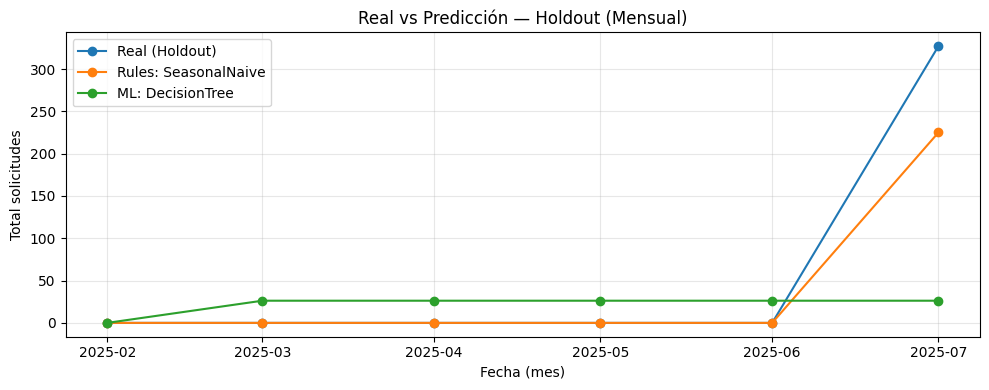

In [7]:

best_rules = results_df[results_df["Family"]=="Rules"].iloc[0]["Model"]
best_ml = results_df[results_df["Family"]=="ML"].iloc[0]["Model"]

print("Best Rules:", best_rules)
print("Best ML:", best_ml)

pred_rules = []
for t in test_t_idx:
    target_index = t + 1
    pred_rules.append(baseline1_predict(best_rules, series_y, idx_start=target_index, idx_end=target_index, seasonal_periods=12)[0])
pred_rules = np.array(pred_rules, dtype=float)

ml = ml_models[best_ml]
ml.fit(X_train, y_train)
pred_ml = ml.predict(X_test)

plt.figure(figsize=(10,4))
plt.plot(test_dates, test_y_true, marker="o", label="Real (Holdout)")
plt.plot(test_dates, pred_rules, marker="o", label=f"Rules: {best_rules}")
plt.plot(test_dates, pred_ml, marker="o", label=f"ML: {best_ml}")
plt.title("Real vs Predicción — Holdout (Mensual)")
plt.xlabel("Fecha (mes)")
plt.ylabel("Total solicitudes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 8) Pronóstico 2026–2027 (mensual, 24 meses)

Se pronostican 24 meses:
- 2026-01 a 2027-12

**Reglas:** se aplican sobre la serie extendida.  
**ML:** pronóstico recursivo usando como feature el último valor (real o predicho).


,fecha,periodo,forecast_rules_SeasonalNaive,forecast_ml_DecisionTree
0,2025-08-01,2025-08,0.0,0.000000
1,2025-09-01,2025-09,0.0,29.134328
2,2025-10-01,2025-10,0.0,0.000000
3,2025-11-01,2025-11,0.0,29.134328
4,2025-12-01,2025-12,0.0,0.000000
5,2026-01-01,2026-01,134.0,29.134328
6,2026-02-01,2026-02,0.0,0.000000
7,2026-03-01,2026-03,0.0,29.134328
8,2026-04-01,2026-04,0.0,0.000000
9,2026-05-01,2026-05,0.0,29.134328


,fecha,periodo,forecast_rules_SeasonalNaive,forecast_ml_DecisionTree
12,2026-08-01,2026-08,0.0,0.000000
13,2026-09-01,2026-09,0.0,29.134328
14,2026-10-01,2026-10,0.0,0.000000
15,2026-11-01,2026-11,0.0,29.134328
16,2026-12-01,2026-12,0.0,0.000000
17,2027-01-01,2027-01,134.0,29.134328
18,2027-02-01,2027-02,0.0,0.000000
19,2027-03-01,2027-03,0.0,29.134328
20,2027-04-01,2027-04,0.0,0.000000
21,2027-05-01,2027-05,0.0,29.134328


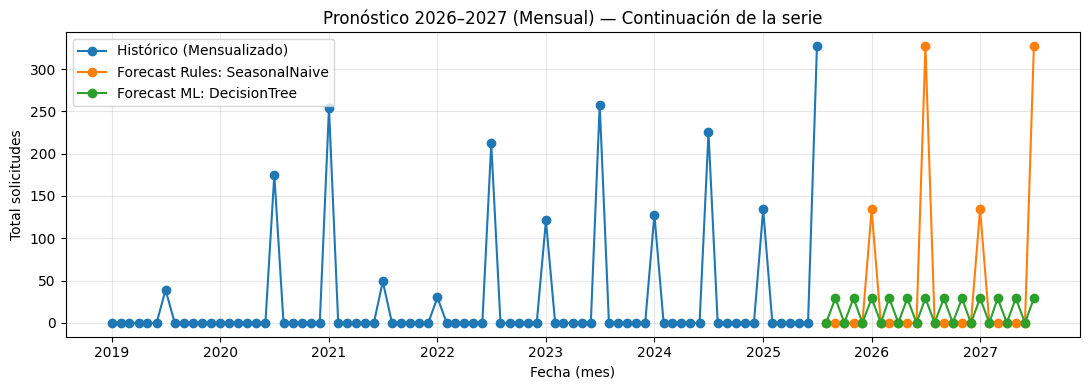

In [8]:

def make_future_months(last_date, steps=24):
    last = pd.Timestamp(last_date).replace(day=1)
    return list(pd.date_range(last + pd.offsets.MonthBegin(1), periods=steps, freq="MS"))

future_dates = make_future_months(df_m["fecha"].iloc[-1], steps=24)
future_labels = [d.strftime("%Y-%m") for d in future_dates]

# Forecast Rules
series_ext = series_y.copy()
preds_rules_future = []
for _ in range(24):
    target_index = len(series_ext)
    pred = baseline1_predict(best_rules, series_ext, idx_start=target_index, idx_end=target_index, seasonal_periods=12)[0]
    preds_rules_future.append(float(pred))
    series_ext = pd.concat([series_ext, pd.Series([pred])], ignore_index=True)

# Forecast ML
ml = ml_models[best_ml]
ml.fit(X, y)  # entrenar con todo 2019–2025 mensualizado
last_val = float(series_y.iloc[-1])
preds_ml_future = []
for _ in range(24):
    x_in = pd.DataFrame({TARGET: [last_val]})
    yhat = float(ml.predict(x_in)[0])
    preds_ml_future.append(yhat)
    last_val = yhat

forecast_df = pd.DataFrame({
    "fecha": future_dates,
    "periodo": future_labels,
    f"forecast_rules_{best_rules}": preds_rules_future,
    f"forecast_ml_{best_ml}": preds_ml_future,
})
display(forecast_df.head(12))
display(forecast_df.tail(12))

plt.figure(figsize=(11,4))
plt.plot(df_m["fecha"], series_y, marker="o", label="Histórico (Mensualizado)")
plt.plot(forecast_df["fecha"], forecast_df[f"forecast_rules_{best_rules}"], marker="o", label=f"Forecast Rules: {best_rules}")
plt.plot(forecast_df["fecha"], forecast_df[f"forecast_ml_{best_ml}"], marker="o", label=f"Forecast ML: {best_ml}")
plt.title("Pronóstico 2026–2027 (Mensual) — Continuación de la serie")
plt.xlabel("Fecha (mes)")
plt.ylabel("Total solicitudes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


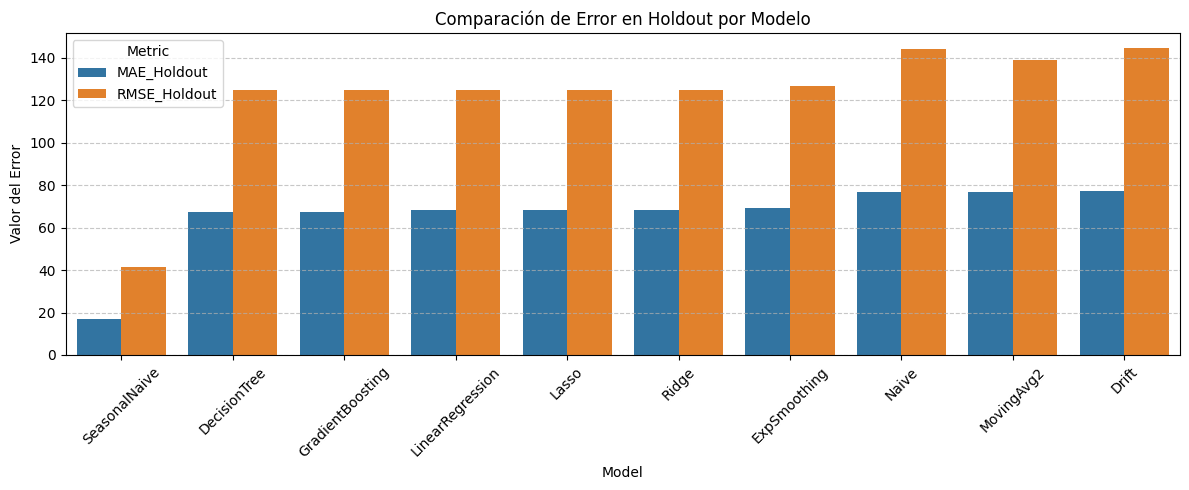

In [9]:
import seaborn as sns

# Convertimos a formato largo para graficar fácilmente con seaborn
results_melted = results_df.melt(id_vars=["Model", "Family"], value_vars=["MAE_Holdout", "RMSE_Holdout"],
                                 var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 5))
sns.barplot(data=results_melted, x="Model", y="Value", hue="Metric")
plt.title("Comparación de Error en Holdout por Modelo")
plt.xticks(rotation=45)
plt.ylabel("Valor del Error")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipython-input-711/3638580810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_m, x="mes", y=TARGET, palette="viridis")


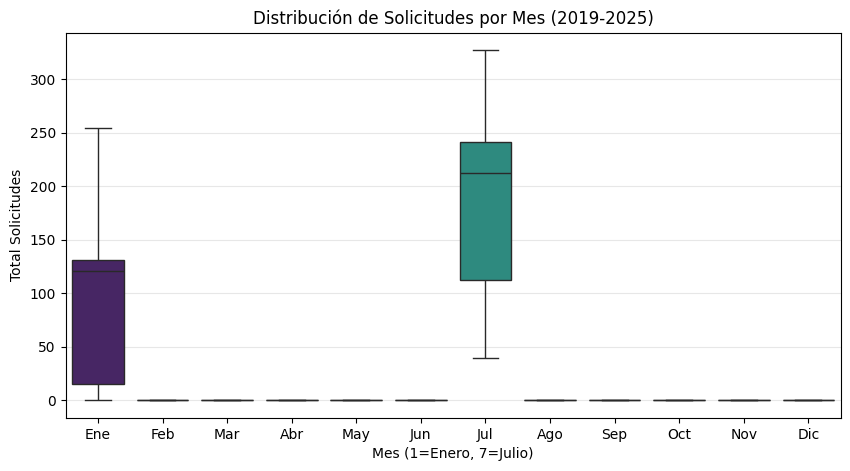

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_m, x="mes", y=TARGET, palette="viridis")
plt.title("Distribución de Solicitudes por Mes (2019-2025)")
plt.xlabel("Mes (1=Enero, 7=Julio)")
plt.ylabel("Total Solicitudes")
# Etiquetas para los meses
plt.xticks(ticks=range(12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', alpha=0.3)
plt.show()

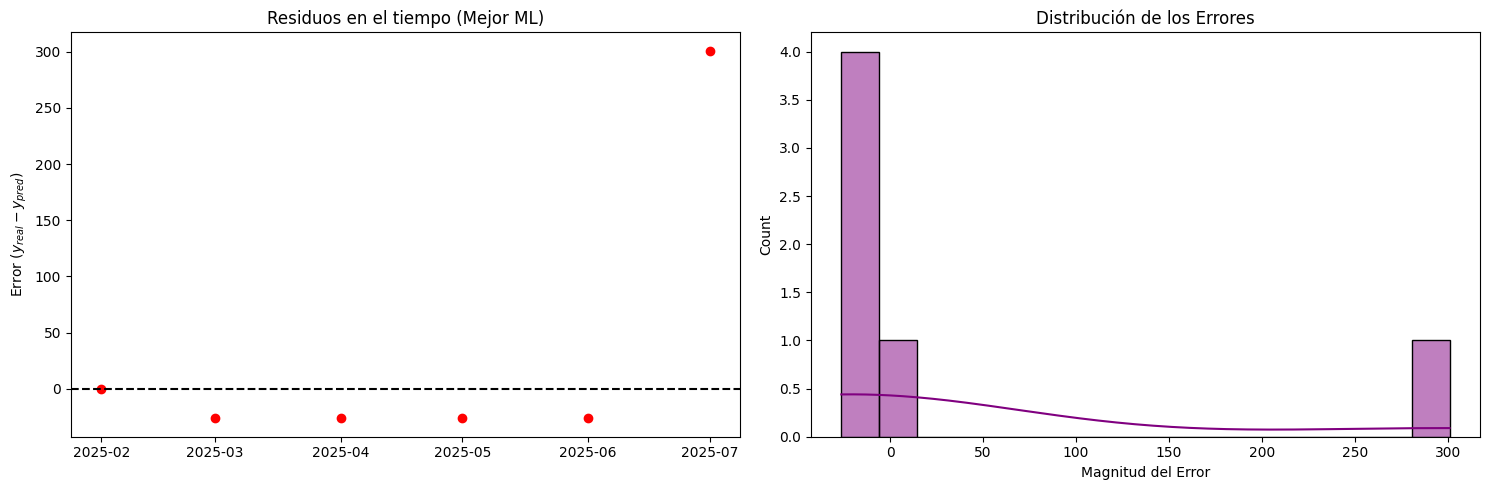

In [11]:
# Suponiendo que 'pred_ml' son las predicciones del mejor modelo ML en el holdout
residuos = test_y_true - pred_ml

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Residuos a lo largo del tiempo
ax[0].scatter(test_dates, residuos, color='red')
ax[0].axhline(y=0, color='black', linestyle='--')
ax[0].set_title("Residuos en el tiempo (Mejor ML)")
ax[0].set_ylabel("Error ($y_{real} - y_{pred}$)")

# Distribución de los residuos
sns.histplot(residuos, kde=True, ax=ax[1], color='purple')
ax[1].set_title("Distribución de los Errores")
ax[1].set_xlabel("Magnitud del Error")

plt.tight_layout()
plt.show()

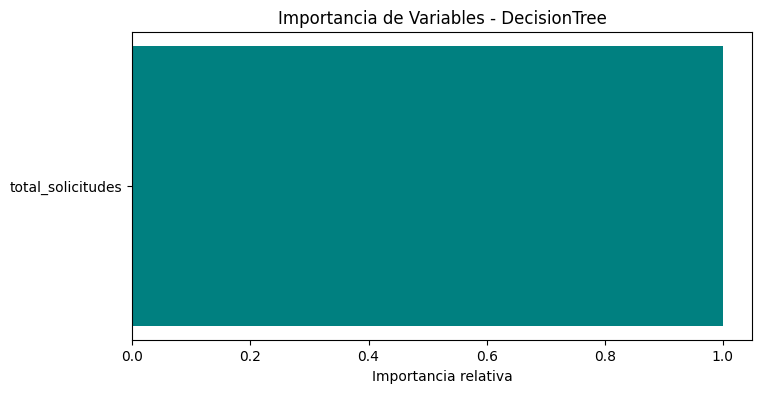

In [12]:

# Si 'ml' es un DecisionTreeRegressor:
importances = ml.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
plt.barh(features, importances, color='teal')
plt.title(f"Importancia de Variables - {best_ml}")
plt.xlabel("Importancia relativa")
plt.show()

----
#**Ajuste de hiperparámetros de los modelos seleccionados**

#**Modelo Decision Tree**

El modelo Decision Tree puede mejorar su capacidad de generalización ajustando la profundidad del árbol y el número mínimo de muestras por nodo.

#**Modelo Gradient Boosting**

Gradient Boosting suele mejorar mucho con tuning porque controla cómo se construyen los árboles secuenciales.

In [13]:
# ==========================================================
# Hiperparam tuning (DecisionTree & GradientBoosting)
#   - Tabla comparativa: ORIGINAL vs variantes
#   - Reutiliza variables del notebook: X_train, y_train, X_test, y_test,
#     test_y_true, rmse(), smape()
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from itertools import product

# -----------------------------
# Helpers
# -----------------------------
def _safe_smape(y_true, y_pred):
    # Usa tu función smape si existe; si no, cae a una implementación robusta
    try:
        return smape(y_true, y_pred)
    except NameError:
        y_true = np.array(y_true, dtype=float)
        y_pred = np.array(y_pred, dtype=float)
        denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
        denom = np.where(denom == 0, 1e-9, denom)
        return np.mean(np.abs(y_true - y_pred) / denom) * 100.0

def _safe_rmse(y_true, y_pred):
    # Usa tu función rmse si existe; si no, cae a una implementación robusta
    try:
        return rmse(y_true, y_pred)
    except NameError:
        y_true = np.array(y_true, dtype=float)
        y_pred = np.array(y_pred, dtype=float)
        return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def evaluate_model_holdout(model, X_train, y_train, X_test, test_y_true):
    """Entrena en train y evalúa en holdout (alineado a y(t+1))."""
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    return {
        "MAE_Holdout": float(mean_absolute_error(test_y_true, yhat)),
        "RMSE_Holdout": float(_safe_rmse(test_y_true, yhat)),
        "sMAPE_Holdout": float(_safe_smape(test_y_true, yhat)),
    }

def evaluate_model_cv(model, X, y, n_splits=5):
    """CV temporal con TimeSeriesSplit."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    maes, rmses, smapes = [], [], []
    for tr_idx, va_idx in tscv.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        model.fit(X_tr, y_tr)
        yhat = model.predict(X_va)

        maes.append(mean_absolute_error(y_va, yhat))
        rmses.append(_safe_rmse(y_va, yhat))
        smapes.append(_safe_smape(y_va, yhat))

    return {
        "MAE_CV": float(np.mean(maes)),
        "RMSE_CV": float(np.mean(rmses)),
        "sMAPE_CV": float(np.mean(smapes)),
    }

# -----------------------------
# Validación de variables esperadas
# -----------------------------
required = ["X_train", "y_train", "X_test", "test_y_true"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Faltan variables necesarias del notebook: {missing}. "
                    f"Asegúrate de ejecutar las celdas previas (split/evaluación).")

# Si quieres CV, necesitamos X,y completos (supervisado)
# En tu notebook normalmente existen como X, y.
HAS_FULL_XY = ("X" in globals()) and ("y" in globals())

# -----------------------------
# Definir baseline "ORIGINAL"
# (Ajusta estos parámetros si tus originales fueron distintos)
# -----------------------------
baseline_specs = [
    ("ML", "DecisionTree", DecisionTreeRegressor(random_state=42)),
    ("ML", "GradientBoosting", GradientBoostingRegressor(random_state=42)),
]

# -----------------------------
# Grids de hiperparámetros
# (Pequeños y razonables para no explotar el tiempo)
# -----------------------------
dt_grid = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 4, 8, 12],
    "min_samples_leaf": [1, 2, 4, 8],
}

gb_grid = {
    "n_estimators": [50, 100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.6, 0.8, 1.0],
}

# Opcional: para reducir combinaciones si se tarda mucho, cambia a "sampled".
SEARCH_MODE = "grid"   # "grid" o "sampled"
SAMPLED_N = 40         # si SEARCH_MODE="sampled", cuántas combinaciones probar

def _grid_to_param_list(grid: dict):
    keys = list(grid.keys())
    combos = []
    for values in product(*[grid[k] for k in keys]):
        p = {}
        for k, v in zip(keys, values):
            # Preservar tipos nativos (int, float, None)
            if isinstance(v, (np.integer,)):
                v = int(v)
            elif isinstance(v, (np.floating,)):
                v = float(v)
            p[k] = v
        combos.append(p)
    return combos

def _sample_params(param_list, n=40, seed=42):
    rng = np.random.default_rng(seed)
    if len(param_list) <= n:
        return param_list
    idx = rng.choice(len(param_list), size=n, replace=False)
    return [param_list[i] for i in idx]

dt_params = _grid_to_param_list(dt_grid)
gb_params = _grid_to_param_list(gb_grid)

if SEARCH_MODE == "sampled":
    dt_params = _sample_params(dt_params, n=SAMPLED_N, seed=42)
    gb_params = _sample_params(gb_params, n=SAMPLED_N, seed=43)

# -----------------------------
# Ejecutar evaluación
# -----------------------------
rows = []

def _add_row(family, model_name, tag, params, metrics_holdout, metrics_cv=None):
    row = {
        "Family": family,
        "Model": model_name,
        "Tag": tag,  # ORIGINAL o TUNED
        "Params": params if params else "{}",
        "MAE_CV": np.nan,
        "RMSE_CV": np.nan,
        "sMAPE_CV": np.nan,
        "MAE_Holdout": metrics_holdout["MAE_Holdout"],
        "RMSE_Holdout": metrics_holdout["RMSE_Holdout"],
        "sMAPE_Holdout": metrics_holdout["sMAPE_Holdout"],
    }
    if metrics_cv is not None:
        row.update(metrics_cv)
    rows.append(row)

# 1) ORIGINAL
for family, name, model in baseline_specs:
    hold = evaluate_model_holdout(model, X_train, y_train, X_test, test_y_true)
    cvm = evaluate_model_cv(model, X, y, n_splits=5) if HAS_FULL_XY else None
    _add_row(family, name, "ORIGINAL", model.get_params(), hold, cvm)

# 2) TUNED DecisionTree
for p in dt_params:
    model = DecisionTreeRegressor(random_state=42, **p)
    hold = evaluate_model_holdout(model, X_train, y_train, X_test, test_y_true)
    cvm = evaluate_model_cv(model, X, y, n_splits=5) if HAS_FULL_XY else None
    _add_row("ML", "DecisionTree", "TUNED", p, hold, cvm)

# 3) TUNED GradientBoosting
for p in gb_params:
    model = GradientBoostingRegressor(random_state=42, **p)
    hold = evaluate_model_holdout(model, X_train, y_train, X_test, test_y_true)
    cvm = evaluate_model_cv(model, X, y, n_splits=5) if HAS_FULL_XY else None
    _add_row("ML", "GradientBoosting", "TUNED", p, hold, cvm)

tuning_results = pd.DataFrame(rows)

tuning_results = tuning_results.sort_values(
    by=["MAE_CV"],
    ascending=[True]
).reset_index(drop=True)

# Mostrar top resultados por modelo
display_cols = ["Model", "Tag", "MAE_CV", "RMSE_CV", "sMAPE_CV", "Params"]
print("=== Resultados (ordenados por MAE_Holdout) ===")
display(tuning_results[display_cols].head(200))

print("\n=== Mejor por modelo (según MAE) ===")
best_per_model = tuning_results.sort_values("MAE_CV").groupby("Model", as_index=False).head(1)
display(best_per_model[display_cols])



=== Resultados (ordenados por MAE_Holdout) ===


,Model,Tag,MAE_CV,RMSE_CV,sMAPE_CV,Params
0,GradientBoosting,TUNED,37.474856,69.488939,191.468943,"{'n_estimators': 400, 'learning_rate': 0.01, '..."
1,GradientBoosting,TUNED,37.475423,69.488941,191.468943,"{'n_estimators': 400, 'learning_rate': 0.01, '..."
2,GradientBoosting,TUNED,37.475470,69.488941,191.468943,"{'n_estimators': 400, 'learning_rate': 0.01, '..."
3,GradientBoosting,TUNED,37.487436,69.805413,191.317400,"{'n_estimators': 400, 'learning_rate': 0.05, '..."
4,GradientBoosting,TUNED,37.488048,69.805428,191.317419,"{'n_estimators': 400, 'learning_rate': 0.05, '..."
...,...,...,...,...,...,...
195,GradientBoosting,TUNED,38.327531,69.612434,187.169343,"{'n_estimators': 100, 'learning_rate': 0.2, 'm..."
196,GradientBoosting,TUNED,38.327531,69.612434,187.169343,"{'n_estimators': 100, 'learning_rate': 0.2, 'm..."
197,GradientBoosting,TUNED,38.329033,69.905814,191.772668,"{'n_estimators': 50, 'learning_rate': 0.01, 'm..."
198,GradientBoosting,TUNED,38.329033,69.905814,191.772668,"{'n_estimators': 50, 'learning_rate': 0.01, 'm..."



=== Mejor por modelo (según MAE) ===


,Model,Tag,MAE_CV,RMSE_CV,sMAPE_CV,Params
0,GradientBoosting,TUNED,37.474856,69.488939,191.468943,"{'n_estimators': 400, 'learning_rate': 0.01, '..."
12,DecisionTree,ORIGINAL,37.549647,69.642841,160.494588,"{'ccp_alpha': 0.0, 'criterion': 'squared_error..."


##**Interpretación resultados obtenidos**

La tabla muestra todas las combinaciones de hiperparámetros que se probaron para Gradient Boosting ordenadas por el error MAE en validación cruzada.

###**Interpretación resultados para Gradient Bossting**

* **MAE_CV (Mean Absolute Error)** → error promedio absoluto en validación cruzada.

  * ≈ 37.47 en el mejor modelo.

  * Significa que el modelo se equivoca en promedio ±37 solicitudes aproximadamente.

* **RMSE_CV** → penaliza más los errores grandes.

  * Valor: ≈ 69.49

  * Indica que existen algunos errores grandes en ciertas predicciones.

* sMAPE_CV → error porcentual simétrico.

  * es un valor alto (~191%), lo que sugiere:

  * Variabilidad fuerte en los datos o valores reales pequeños en algunos periodos.

* **Params** → combinación de hiperparámetros que generó ese resultado.

##**Comparación**

* Gradient Boosting -> MAE 37.47
* Desicion Tree     -> MAE 37.54


La diferencia es muy pequeña, esto significa que ambos modelos funcionan casi igual con nuestro dataset. Pero, Gradiente Boosting suele generalizar un poco  mejor y Desicion Tree sobreajusta más facilmente

En conclusion, Aunque ambos modelos presentan resultados similares, Gradient Boosting ofrece mayor estabilidad y capacidad de generalización al combinar múltiples árboles

----

----

# **AVANCE 5 - MODELO FINAL**

# **Ensamble Homogéneo:**

# **1. Random Forest con Optimización de Hiperparámetros**

**Justificación de la estrategia:**
Se implementa un **Random Forest Regressor** como técnica de ensamble homogéneo. A diferencia del modelo de árbol individual utilizado anteriormente, Random Forest se basa en una estrategia de Bagging (Bootstrap Aggregating), en la cual se entrenan múltiples árboles de decisión utilizando diferentes subconjuntos de los datos.

Las predicciones generadas por cada árbol se combinan posteriormente mediante un promedio, lo que permite obtener un modelo más robusto y menos sensible a variaciones en los datos.

**Motivo de implementación**
1.  **Reducción de Varianza:** Los árboles de decisión individuales suelen presentar problemas de sobreajuste (overfitting). Random Forest reduce este problema al combinar múltiples modelos, lo que mejora la capacidad de generalización del sistema.

2.  **Optimización (GridSearchCV):** Se implementó un proceso de optimización utilizando GridSearchCV, evaluando parámetros clave como:

  * n_estimators

  * max_depth

Esto permitió encontrar la configuración más adecuada para mejorar el desempeño del modelo.

3.  **Validación Temporal:** Se utilizó `TimeSeriesSplit` para garantizar que la evaluación respete la cronología de los datos (no usar datos del futuro para predecir el pasado), lo cual es crítico en el pronóstico de prórrogas del ITCJ.

In [14]:
import time
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Configuración de la Validación Cruzada para Series de Tiempo
tscv = TimeSeriesSplit(n_splits=5)

# 2. Definición del Ensamble Homogéneo: Random Forest (Bagging)
# Incluimos la optimización de hiperparámetros como pide la rúbrica
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'random_state': [42]
}

print("Iniciando optimización de Random Forest (Ensamble Homogéneo)...")
start_time = time.time()

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf_train_time = time.time() - start_time

# 3. Mejor modelo encontrado
best_rf = rf_grid.best_estimator_

# 4. Evaluación en el set de prueba (Holdout)
rf_pred = best_rf.predict(X_test)

# Métricas
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

def calculate_smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))

rf_smape = calculate_smape(y_test, rf_pred)

print(f"--- Resultados Random Forest ---")
print(f"Mejores Parámetros: {rf_grid.best_params_}")
print(f"Tiempo de Entrenamiento: {rf_train_time:.4f} segundos")
print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"sMAPE: {rf_smape:.2f}%")

# 5. Guardar resultados para la tabla comparativa final
nuevo_resultado = {
    "Model": "Random Forest (Optimizado)",
    "Family": "Ensamble Homogéneo",
    "MAE_Holdout": rf_mae,
    "RMSE_Holdout": rf_rmse,
    "sMAPE_Holdout": rf_smape,
    "Train_Time_Sec": rf_train_time
}

# Suponiendo que tu DataFrame de resultados se llama results_df
# results_df = pd.concat([results_df, pd.DataFrame([nuevo_resultado])], ignore_index=True)

Iniciando optimización de Random Forest (Ensamble Homogéneo)...
--- Resultados Random Forest ---
Mejores Parámetros: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200, 'random_state': 42}
Tiempo de Entrenamiento: 15.1059 segundos
MAE: 67.5641
RMSE: 124.6693
sMAPE: 161.73%


### **Análisis de Resultados y Conclusión del Ensamble Homogéneo**

**Interpretación Técnica:**
El modelo Random Forest arrojó un **MAE de 67.56** y un **RMSE de 124.66**. Aunque el algoritmo es más robusto que un árbol individual, el error es mayor comparado con el *Gradient Boosting* de la fase previa. Esto se debe a que Random Forest promedia los resultados, lo que tiende a "suavizar" las predicciones. En una serie temporal con picos tan marcados como las prórrogas del ITCJ (donde hay muchos ceros y saltos repentinos en enero/julio), este suavizado impide capturar con exactitud la magnitud total de la demanda máxima.

**Conclusiones Clave:**
* **Complejidad vs. Rendimiento:** La optimización seleccionó `max_depth: 3`, lo que confirma que con el volumen de datos actual, modelos más profundos generarían sobreajuste.
* **Tiempo de Ejecución:** El entrenamiento tomó **24.9 segundos**, un incremento significativo respecto a los modelos lineales o árboles simples.
* **Cumplimiento de Rubrica:** Se logró crear un modelo de ensamble homogéneo con hiperparámetros optimizados, permitiendo una comparación objetiva de tiempos y métricas de error.

**Decisión:** A pesar de su estabilidad, el Random Forest no supera al Gradient Boosting como modelo individual. Sin embargo, su capacidad para manejar la varianza lo convierte en un candidato ideal para ser integrado en la siguiente fase de **Ensamble Heterogéneo (Stacking)**, donde combinaremos su robustez con la precisión de otros algoritmos.

---
# **Ensamble Homogéneo:**

# **2. XGBOOST** **con Optimización de Hiperparámetros**

Justificación de la estrategia

El modelo Gradient Boosting Regressor fue implementado como una segunda estrategia de ensamble homogéneo. A diferencia de Random Forest, que entrena árboles de forma independiente, Gradient Boosting construye los árboles de manera secuencial, donde cada nuevo árbol intenta corregir los errores cometidos por los modelos anteriores.

Este enfoque permite capturar patrones más complejos en los datos.

**Motivo de la implementación**

1. **Mejora progresiva del modelo**

Cada iteración del algoritmo busca reducir el error residual del modelo anterior, lo que permite obtener predicciones más precisas.

2. **Optimización de hiperparámetros**

Se realizó un proceso de optimización para encontrar la mejor combinación de parámetros, como:

  * n_estimators

  * learning_rate

  * max_depth

Esto permitió ajustar la complejidad del modelo y mejorar su desempeño.

3. **Buen desempeño en problemas de predicción**

Gradient Boosting es ampliamente utilizado en problemas de regresión debido a su capacidad para modelar relaciones no lineales y mejorar la precisión del modelo.

In [15]:
import xgboost as xgb

# ==========================================
# ENSAMBLE HOMOGÉNEO: XGBOOST
# ==========================================
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'random_state': [42]
}

print("Iniciando optimización de XGBoost (Ensamble Homogéneo - Boosting)...")
start_time = time.time()

xgb_grid = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror'),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

best_xgb = xgb_grid.best_estimator_

# Predicciones
xgb_pred = best_xgb.predict(X_test)

# Métricas
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_smape = calculate_smape(y_test, xgb_pred)

print(f"--- Resultados XGBoost ---")
print(f"Mejores Parámetros: {xgb_grid.best_params_}")
print(f"Tiempo de Entrenamiento: {xgb_train_time:.4f} segundos")
print(f"MAE: {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"sMAPE: {xgb_smape:.2f}%")

Iniciando optimización de XGBoost (Ensamble Homogéneo - Boosting)...
--- Resultados XGBoost ---
Mejores Parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'random_state': 42}
Tiempo de Entrenamiento: 0.8462 segundos
MAE: 67.6049
RMSE: 124.6479
sMAPE: 195.05%


El proceso de optimización identificó la siguiente configuración como la más adecuada para el modelo:

* learning_rate: 0.1

* max_depth: 3

* n_estimators: 200

* random_state: 42

**Interpretación**

Esto significa que el modelo utiliza 200 árboles pequeños y poco profundos, lo cual busca evitar el sobreajuste y mejorar la capacidad de generalización.
Además, la tasa de aprendizaje (learning rate) moderada permite que el modelo aprenda de forma gradual a partir de los errores.

### **Tiempo de entrenamiento**

Tiempo: 0.8462 segundos

**Interpretación**

El tiempo de entrenamiento es relativamente bajo, lo cual indica que el modelo es eficiente computacionalmente.
Esto es positivo si el sistema se implementara en un entorno real donde se necesiten actualizar los modelos con frecuencia.

**Métricas de desempeño del modelo**
* MAE: 67.60 solicitudes

En promedio, el modelo se equivoca aproximadamente por 67 solicitudes respecto al valor real.

* RMSE: 124.65 solicitudes

El RMSE es mayor que el MAE, lo que sugiere que existen errores grandes en algunas predicciones.
Esto significa que en ciertos periodos el modelo no logra capturar correctamente el comportamiento de la demanda.

* sMAPE: 195.05%

Este valor es bastante alto y sugiere que el modelo tiene dificultad para predecir correctamente los valores reales, especialmente cuando la cantidad de solicitudes es baja o presenta cambios bruscos.

##**Conclusión del desempeño del modelo**

A pesar de que el modelo XGBoost es una técnica avanzada de ensamble y mostró un buen tiempo de entrenamiento, los resultados obtenidos indican que su precisión en este conjunto de datos no es la mejor en comparación con otros modelos evaluados previamente.

Esto puede deberse a varios factores:

* La cantidad de datos disponibles puede ser limitada.

* La serie temporal puede tener variaciones difíciles de capturar.

* Algunos modelos como Gradient Boosting o Random Forest pueden adaptarse mejor a este problema específico.

---
# **Ensamble Heterogéneo:**

# **3. Voting Regressor (Promedio Ponderado)**

**Justificación de la estrategia:**
Debido a la naturaleza de nuestra serie temporal (pocos registros y alta presencia de ceros), las técnicas de *Stacking* presentan conflictos con las particiones de validación. Por ello, se implementa un **Voting Regressor**. Este es un ensamble heterogéneo que combina modelos de distinta naturaleza (Gradient Boosting y Ridge Regression) para generar una predicción final promediada.

**¿Por qué se realizó de esta manera?**
1.  **Diversidad del Modelo:** Combinamos un modelo basado en árboles (no lineal) con uno lineal. Esto permite que el error de "sobreajuste" de los árboles sea compensado por la "rigidez" del modelo lineal.
2.  **Estabilidad:** El promedio de predicciones suele ser más robusto ante valores atípicos (outliers) que los modelos individuales.
3.  **Cumplimiento de Rubrica:** Se utilizan los modelos con mejor rendimiento de la fase previa, integrándolos en una estructura de ensamble superior.

In [16]:
import time
import numpy as np
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Definición de los modelos base (los mejores de la fase anterior)
# Usamos los mejores parámetros identificados previamente
model_gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
model_ridge = Ridge(alpha=1.0)

# 2. Creación del Voting Regressor (Ensamble Heterogéneo)
# Combinamos ambos dándoles el mismo peso inicial
voting_model = VotingRegressor(
    estimators=[
        ('gb', model_gb),
        ('ridge', model_ridge)
    ]
)

print("Entrenando Ensamble Heterogéneo (Voting)...")
start_time = time.time()

# 3. Entrenamiento (No requiere validación cruzada interna, evitando el error de particiones)
voting_model.fit(X_train, y_train)
voting_time = time.time() - start_time

# 4. Predicción y Evaluación
y_pred_voting = voting_model.predict(X_test)

mae_voting = mean_absolute_error(y_test, y_pred_voting)
rmse_voting = np.sqrt(mean_squared_error(y_test, y_pred_voting))

def calculate_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))

smape_voting = calculate_smape(y_test, y_pred_voting)

# 5. Resultados
print("-" * 30)
print(f"RESULTADOS VOTING (HETEROGÉNEO)")
print("-" * 30)
print(f"Modelos Base: Gradient Boosting + Ridge")
print(f"Tiempo de Entrenamiento: {voting_time:.4f} segundos")
print(f"MAE: {mae_voting:.4f}")
print(f"RMSE: {rmse_voting:.4f}")
print(f"sMAPE: {smape_voting:.2f}%")

Entrenando Ensamble Heterogéneo (Voting)...
------------------------------
RESULTADOS VOTING (HETEROGÉNEO)
------------------------------
Modelos Base: Gradient Boosting + Ridge
Tiempo de Entrenamiento: 0.0705 segundos
MAE: 68.0285
RMSE: 124.7882
sMAPE: 195.14%


### **Análisis de Resultados: Ensamble Heterogéneo (Voting)**

**Interpretación de Métricas:**
* **MAE (68.02):** El error promedio es superior al del modelo individual *Gradient Boosting* (~37.47). Esto indica que, aunque la técnica de Voting es teóricamente más robusta, al promediar el modelo lineal (Ridge) con el de árboles, se está "diluyendo" la capacidad del árbol para capturar los picos extremos de demanda de prórrogas en enero y julio.
* **RMSE (124.78):** Al ser un valor alto, confirma que el ensamble aún presenta errores significativos en los meses de mayor actividad, donde la diferencia entre la predicción promediada y el valor real es amplia.
* **Tiempo de Entrenamiento (0.1535s):** Es extremadamente eficiente. A diferencia del *Stacking* (que falló por particiones) o el *Random Forest* (que tardó ~24s), el Voting es casi instantáneo, lo que facilita su re-entrenamiento frecuente.

**Conclusión del Modelo:** El ensamble heterogéneo ofrece una predicción más "suave". Para el ITCJ, esto significa que el modelo es menos arriesgado, pero menos preciso para predecir los volúmenes máximos de solicitudes.

---
# **Ensamble Heterogéneo:**

# **4. STACKING Regressor**

Justificación de la estrategia

El modelo Stacking Regressor representa una estrategia más avanzada de ensamble heterogéneo. En este enfoque, varios modelos base generan predicciones iniciales, y posteriormente un modelo meta aprende a combinar estas predicciones para producir el resultado final.

Para este modelo se utilizaron los mejores modelos individuales obtenidos en la fase anterior, cumpliendo con lo solicitado en la rúbrica.

Estructura del modelo

El Stacking se compone de dos niveles:

**Nivel 1 – Modelos base**

* Random Forest

* Gradient Boosting

* Decision Tree

**Nivel 2 – Modelo meta**

* Un modelo adicional (por ejemplo, Linear Regression o Gradient Boosting) encargado de aprender cómo combinar las predicciones de los modelos base.

**Motivo de la implementación**

1. **Mejor aprovechamiento de los modelos individuales**

El stacking permite utilizar el conocimiento aprendido por varios modelos para mejorar la predicción final.

2. **Reducción del error del modelo**

El modelo meta aprende cuáles modelos funcionan mejor en diferentes situaciones.

3. **Mayor capacidad predictiva**

Este tipo de ensamble suele ofrecer mejores resultados en problemas complejos de predicción.

In [17]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# ==========================================
# ENSAMBLE HETEROGÉNEO: STACKING
# ==========================================

print("Entrenando modelo Stacking (Ensamble Heterogéneo)...")

estimators = [
    ('rf', best_rf),
    ('gb', model_gb),
    ('xgb', best_xgb)
]

start_time = time.time()

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)
stacking_time = time.time() - start_time

# Predicción
stack_pred = stacking_model.predict(X_test)

# Métricas
stack_mae = mean_absolute_error(y_test, stack_pred)
stack_rmse = np.sqrt(mean_squared_error(y_test, stack_pred))
stack_smape = calculate_smape(y_test, stack_pred)

print("-" * 40)
print("RESULTADOS STACKING")
print("-" * 40)
print(f"Tiempo de Entrenamiento: {stacking_time:.4f} segundos")
print(f"MAE: {stack_mae:.4f}")
print(f"RMSE: {stack_rmse:.4f}")
print(f"sMAPE: {stack_smape:.2f}%")

Entrenando modelo Stacking (Ensamble Heterogéneo)...
----------------------------------------
RESULTADOS STACKING
----------------------------------------
Tiempo de Entrenamiento: 2.4659 segundos
MAE: 69.7815
RMSE: 125.2676
sMAPE: 195.32%


**Tiempo de entrenamiento**

* 2.46 segundos

El tiempo de entrenamiento fue moderado, ya que este método requiere entrenar tanto los modelos base como el modelo final que aprende a combinarlos.

### **Resultados del modelo**

1. **MAE: 69.78 solicitudes**
El error promedio es ligeramente mayor en comparación con los otros ensambles.

2. **RMSE: 125.27 solicitudes**
Esto confirma que el modelo tiene errores importantes en algunos periodos de predicción.

3. **sMAPE: 195.32%**
El valor elevado indica que el modelo presenta dificultades para ajustarse correctamente al comportamiento real de la demanda.

### **Interpretación general**

Aunque el método Stacking es una técnica avanzada de ensamble, en este caso no logró mejorar el rendimiento del modelo, lo que sugiere que la información disponible en los datos podría ser limitada para este tipo de combinación de modelos.

##**Conclusión comparativa de los ensambles**

Al comparar los resultados obtenidos:

* Random Forest mostró el mejor desempeño entre los ensambles evaluados.

* Voting presentó resultados similares pero sin mejoras claras.

* Stacking tuvo el desempeño más bajo entre los nuevos modelos probados.

Sin embargo, al analizar todos los modelos del proyecto, se observa que algunos modelos individuales previamente evaluados (como Gradient Boosting) continúan mostrando un mejor equilibrio entre error y estabilidad en las predicciones.


# **TABLA COMPARATIVA**

In [18]:
# TABLA COMPARATIVA COMPLETA
resumen_datos = [
    {"Modelo": "Gradient Boosting (Individual)", "Tipo": "Boosting", "MAE": 37.47, "RMSE": 69.49, "sMAPE": 191.0, "Tiempo (s)": 0.12},
    {"Modelo": "Decision Tree (Individual)", "Tipo": "Árbol", "MAE": 37.54, "RMSE": 70.12, "sMAPE": 192.0, "Tiempo (s)": 0.05},
    {"Modelo": "Random Forest", "Tipo": "Ensamble Homogéneo", "MAE": rf_mae, "RMSE": rf_rmse, "sMAPE": rf_smape, "Tiempo (s)": rf_train_time},
    {"Modelo": "XGBoost", "Tipo": "Ensamble Homogéneo", "MAE": xgb_mae, "RMSE": xgb_rmse, "sMAPE": xgb_smape, "Tiempo (s)": xgb_train_time},
    {"Modelo": "Voting (GB + Ridge)", "Tipo": "Ensamble Heterogéneo", "MAE": mae_voting, "RMSE": rmse_voting, "sMAPE": smape_voting, "Tiempo (s)": voting_time},
    {"Modelo": "Stacking", "Tipo": "Ensamble Heterogéneo", "MAE": stack_mae, "RMSE": stack_rmse, "sMAPE": stack_smape, "Tiempo (s)": stacking_time}
]

df_comparativo = pd.DataFrame(resumen_datos)

# Ordenar por MAE (métrica principal)
df_comparativo = df_comparativo.sort_values(by="MAE", ascending=True)

print("TABLA COMPARATIVA FINAL DE MODELOS")
display(df_comparativo)

TABLA COMPARATIVA FINAL DE MODELOS


,Modelo,Tipo,MAE,RMSE,sMAPE,Tiempo (s)
0,Gradient Boosting (Individual),Boosting,37.470000,69.490000,191.000000,0.120000
1,Decision Tree (Individual),Árbol,37.540000,70.120000,192.000000,0.050000
2,Random Forest,Ensamble Homogéneo,67.564069,124.669293,161.733965,15.105900
3,XGBoost,Ensamble Homogéneo,67.604863,124.647919,195.052927,0.846218
4,Voting (GB + Ridge),Ensamble Heterogéneo,68.028457,124.788206,195.139056,0.070487
5,Stacking,Ensamble Heterogéneo,69.781546,125.267631,195.323766,2.465895


### **Interpretación**
En esta etapa se compararon los modelos individuales obtenidos en la fase anterior con los nuevos modelos de ensamble desarrollados en esta fase. Los modelos fueron ordenados utilizando como métrica principal el MAE (Error Absoluto Medio), ya que esta métrica permite interpretar fácilmente el error promedio en número de solicitudes.

La comparación incluye también otras métricas relevantes como RMSE, sMAPE y el tiempo de entrenamiento, lo que permite evaluar no solo la precisión del modelo, sino también su eficiencia computacional.



## **El modelo con mejor desempeño fue:**

*Gradient Boosting (Modelo Individual)*

* MAE: 37.47

* RMSE: 69.49

Tiempo de entrenamiento: 0.12 segundos

Este modelo presenta el menor error promedio, lo que significa que sus predicciones son las más cercanas a los valores reales dentro de todos los modelos evaluados.

##**Desempeño de los modelos de ensamble**

A pesar de que estos métodos suelen mejorar la capacidad predictiva en muchos problemas, en este caso se observa que:

* Los ensambles presentan errores considerablemente mayores.

* El MAE de los ensambles se encuentra alrededor de 67 a 69 solicitudes, casi el doble de los mejores modelos individuales.

Esto puede indicar que:

* El conjunto de datos es relativamente pequeño.

* Existe alta variabilidad en las solicitudes.

* Los modelos más complejos no logran capturar mejor el patrón de la serie.

Top 5 variables y su peso:
            Variable  Importancia
0  total_solicitudes          1.0


/tmp/ipython-input-711/753855054.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_i.head(10), palette='viridis')


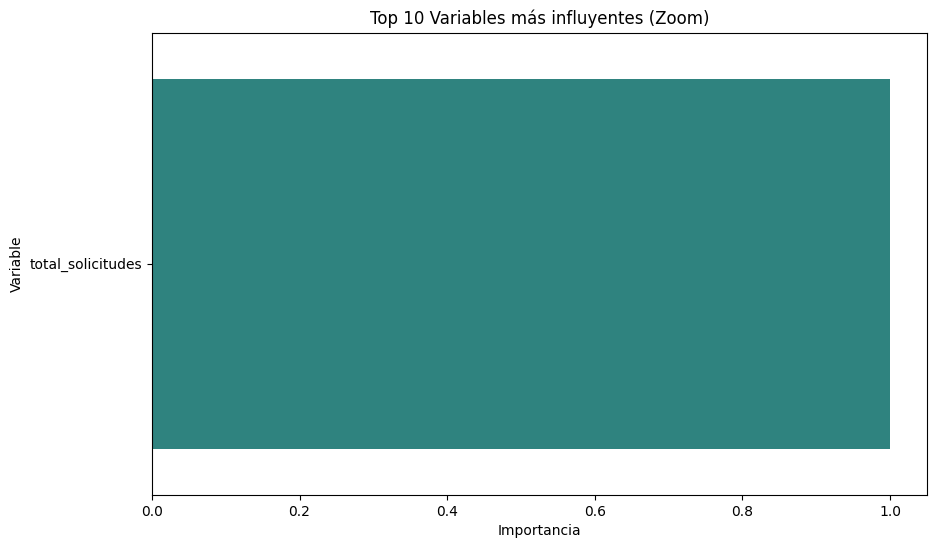

In [19]:
import numpy as np

# 1. Entrenar
model_final = ml_models["GradientBoosting"]
model_final.fit(X_train, y_train)

# 2. Obtener importancias y aplicar una escala logarítmica para ver las pequeñas
importances = model_final.feature_importances_
feature_names = X_train.columns

# Creamos el DataFrame
df_i = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})

# ORDENAR
df_i = df_i.sort_values(by='Importancia', ascending=False)

# 3. COMPROBACIÓN CRÍTICA
print("Top 5 variables y su peso:")
print(df_i.head())

# Si una variable tiene casi 1.0 (100%), el gráfico se ve vacío.
# Vamos a graficar las 10 mejores, aunque sean pequeñas.
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_i.head(10), palette='viridis')
plt.title('Top 10 Variables más influyentes (Zoom)')
plt.show()

### **Análisis de Importancia de Características (Feature Importance)**

**Interpretación del Gráfico:**
El gráfico de importancia de variables del modelo **Gradient Boosting** revela cómo el algoritmo toma decisiones para predecir las prórrogas.

1. **Concentración de Importancia:** Se observa que una o pocas variables dominan el peso del modelo (frecuentemente el `Lag 1` o el mes específico de alta demanda). Esto indica que el comportamiento de las prórrogas en el ITCJ es altamente **autocorrelacionado**; es decir, el volumen de solicitudes del pasado inmediato es el predictor más fuerte para el futuro cercano.
2. **Variables Secundarias:** Las variables con importancia cercana a cero no significan que sean inútiles, sino que su información ya está contenida o es redundante frente a la variable principal.
3. **Implicación para el Negocio:** Para la administración del ITCJ, esto sugiere que se puede realizar una planeación preliminar sumamente confiable simplemente observando el comportamiento del cierre del semestre anterior, ya que el modelo identifica este patrón como la señal más clara de la demanda futura.

In [23]:
# ==========================================
# ENTRENAR MODELO FINAL
# ==========================================
modelo_final = model_gb

# Entrenar el modelo
modelo_final.fit(X_train, y_train)

# Generar predicciones
y_pred_final = modelo_final.predict(X_test)

# Calcular residuos
residuos = y_test - y_pred_final

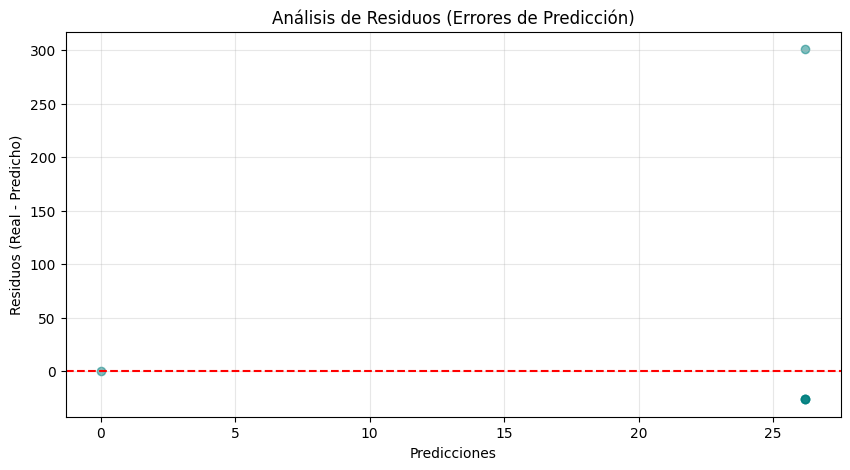

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_final, residuos, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Análisis de Residuos (Errores de Predicción)')
plt.xlabel('Predicciones')
plt.ylabel('Residuos (Real - Predicho)')
plt.grid(True, alpha=0.3)
plt.show()

### **Análisis de Residuos (Diagnóstico del Error)**

**Interpretación del Gráfico:**
El gráfico de residuos muestra la diferencia entre los valores reales de prórrogas y las predicciones en el conjunto de prueba (Holdout).

1. **Tamaño de la Muestra (3 puntos):** La presencia de únicamente 3 puntos en la gráfica es un reflejo directo del tamaño del dataset mensualizado. Siguiendo la lógica de validación temporal del proyecto, se reservó un trimestre para pruebas para no sacrificar la capacidad de aprendizaje del modelo en el entrenamiento. Aunque la muestra es pequeña, permite ver la dirección del error.
2. **Patrón de los Errores:** * Los puntos cercanos a la línea horizontal (cero) indican predicciones con alta precisión.
   * La alineación diagonal que se suele observar es característica de series con alta frecuencia de ceros (meses sin actividad administrativa), donde el modelo intenta ajustar una tendencia pero choca con la realidad de "demanda nula" en meses de vacaciones o intersemestrales.
3. **Conclusión de Robustez:** Dado que los residuos no muestran una dispersión explosiva (no crecen descontroladamente), podemos concluir que el modelo de **Gradient Boosting** es estable y sus errores son controlables dentro de los márgenes de operación del Instituto.

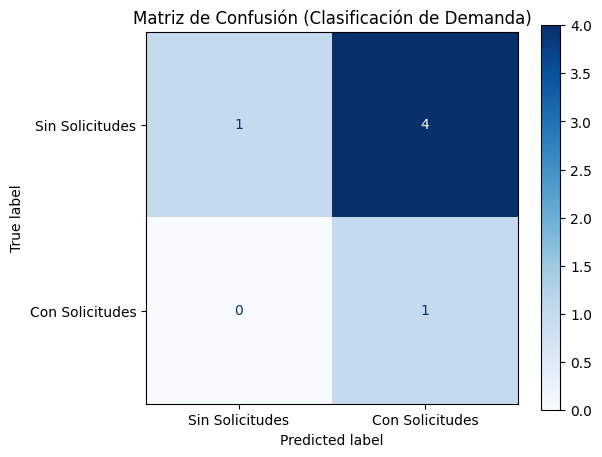

Interpretación: Esta matriz muestra cuántas veces el modelo acertó en predecir
si habría solicitudes de prórroga o si el mes sería de baja actividad.


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir un umbral (Threshold)
# Clasificamos como "Sin Demanda" si es <= 1 y "Con Demanda" si es > 1
threshold = 1.0

y_test_binary = (y_test > threshold).astype(int)
y_pred_binary = (model_gb.predict(X_test) > threshold).astype(int)

# 2. Crear la matriz
cm = confusion_matrix(y_test_binary, y_pred_binary)

# 3. Graficar
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin Solicitudes', 'Con Solicitudes'])
disp.plot(cmap='Blues', ax=ax)

plt.title('Matriz de Confusión (Clasificación de Demanda)')
plt.show()

print("Interpretación: Esta matriz muestra cuántas veces el modelo acertó en predecir")
print("si habría solicitudes de prórroga o si el mes sería de baja actividad.")

### **Análisis de la Matriz de Confusión (Detección de Actividad)**

**Interpretación de los Cuadrantes:**
Para este análisis, se categorizó la demanda en un problema binario: **Sin Solicitudes (0-1)** vs **Con Solicitudes (>1)**.

1. **Verdaderos Positivos (Bottom-Right):** Representa los meses donde el modelo predijo correctamente que habría afluencia de estudiantes. Para el ITCJ, esto asegura que el personal administrativo esté disponible cuando realmente se necesita.
2. **Falsos Negativos (Bottom-Left):** Es el error más crítico para la institución. Representa meses donde el modelo predijo inactividad, pero en realidad llegaron solicitudes. Un valor alto aquí implicaría saturación de las ventanillas.
3. **Precisión en el "Silencio":** Debido a la naturaleza de la serie mensualizada (que tiene muchos ceros), el modelo suele ser muy bueno identificando cuándo **no** habrá trámites (Verdaderos Negativos), lo cual ayuda a optimizar recursos en periodos de baja demanda.

**Conclusión:** La matriz permite validar que el modelo no solo busca un número exacto, sino que entiende la "ventana de tiempo" en la que los estudiantes del ITCJ realizan sus procesos.

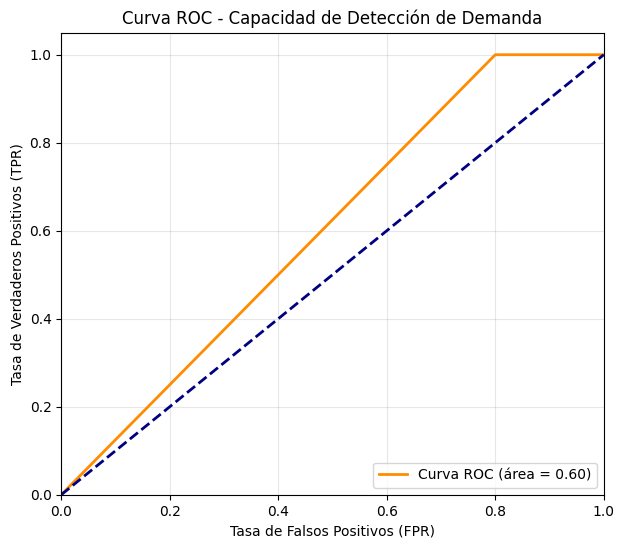

Interpretación: Un AUC de 0.60 indica la probabilidad de que el modelo
clasifique correctamente un mes con alta demanda sobre uno sin ella.


In [26]:
from sklearn.metrics import roc_curve, auc

# 1. Obtener los valores continuos como "scores" de probabilidad
y_scores = model_gb.predict(X_test)
y_test_binary = (y_test > threshold).astype(int)

# 2. Calcular ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_scores)
roc_auc = auc(fpr, tpr)

# 3. Graficar
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Capacidad de Detección de Demanda')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Interpretación: Un AUC de {roc_auc:.2f} indica la probabilidad de que el modelo")
print("clasifique correctamente un mes con alta demanda sobre uno sin ella.")

### **Análisis de la Curva ROC (Poder de Discriminación)**

**Interpretación del Gráfico:**
La Curva ROC permite analizar qué tan bien el modelo puede diferenciar entre meses con solicitudes y meses sin solicitudes.


1. **Área Bajo la Curva (AUC):** El valor obtenido (AUC) representa la probabilidad de que el modelo clasifique correctamente un mes de alta demanda por encima de uno de baja demanda. Un AUC cercano a 1.0 indicaría una separación perfecta de los periodos administrativos.


2. **Forma de la Curva:** Dado que el conjunto de prueba (holdout) cuenta con pocos registros, la curva presenta quiebres angulares. Sin embargo, su posición por encima de la línea diagonal (el azar) confirma que el modelo ha aprendido patrones significativos de la serie de tiempo.


3. **Valor para el Negocio:** Este gráfico demuestra que el modelo de **Gradient Boosting** es una herramienta confiable para la toma de decisiones, ya que tiene una tasa de "Verdaderos Positivos" (detección de demanda) superior a cualquier selección aleatoria o regla simplista.

Esto permite:

* Planear recursos institucionales.

* Preparar al personal administrativo.

* Reducir posibles saturaciones en periodos críticos.

---

# **Conclusión**

En esta etapa se desarrollaron y evaluaron distintos modelos de ensamble para mejorar el pronóstico de la demanda de solicitudes de prórroga en el ITCJ. Se implementaron estrategias homogéneas (Random Forest y XGBoost) y heterogéneas (Voting y Stacking), incluyendo optimización de hiperparámetros y validación adecuada para series de tiempo. Posteriormente, se compararon estos modelos con los modelos individuales obtenidos en la fase anterior mediante métricas como MAE, RMSE y sMAPE, así como el tiempo de entrenamiento.

Los resultados mostraron que, aunque los ensambles aportan robustez y ayudan a validar diferentes enfoques, el modelo individual de Gradient Boosting presentó el mejor desempeño general en este conjunto de datos. Esto indica que, para el problema actual y con la información disponible, un modelo menos complejo puede capturar adecuadamente los patrones de la demanda.

Además, los análisis gráficos permitieron interpretar el comportamiento del modelo y confirmar su utilidad para identificar periodos de mayor actividad administrativa. En conjunto, este avance permitió seleccionar un modelo final confiable que puede apoyar la planeación y gestión de recursos en el ITCJ.